In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
file_path = "../data/diabetes_cleaned1.csv"
df = pd.read_csv(file_path)
df1 = pd.read_csv('../data/diabetes_dataset1.csv')
print("✅ Loaded cleaned dataset:", df.shape)
df.head()


✅ Loaded cleaned dataset: (10000, 29)


,Age,Sex,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Dietary_Intake_Calories,Family_History_of_Diabetes,Previous_Gestational_Diabetes,Ethnicity_Asian,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_White,Physical_Activity_Level_High,Physical_Activity_Level_Low,Physical_Activity_Level_Moderate,Alcohol_Consumption_Heavy,Alcohol_Consumption_Moderate,Alcohol_Consumption_None,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never
0,58,0,35.8,83.4,123.9,10.9,152,114,197.8,50.2,99.2,37.5,7.2,1538,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1
1,48,1,24.1,71.4,183.7,12.8,103,91,261.6,62.0,146.4,88.5,6.1,2653,0,1,1,0,0,0,0,0,1,0,1,0,1,0,0
2,34,0,25.0,113.8,142.0,14.5,179,104,261.0,32.1,164.1,56.2,6.9,1684,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0
3,62,1,32.7,100.4,167.4,8.8,176,118,183.4,41.1,84.0,34.4,5.4,3796,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1
4,27,0,33.5,110.8,146.4,7.1,122,97,203.2,53.9,92.8,81.9,7.4,3161,0,0,1,0,0,0,0,0,1,1,0,0,1,0,0


In [3]:
df1.head()

,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes,Diabetes
0,58,Female,White,35.8,83.4,123.9,10.9,152,114,197.8,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1,0
1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,261.6,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1,1
2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,261.0,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0,1
3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,183.4,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0,1
4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,203.2,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0,1


In [4]:
# Create a new binary target column 'Diabetes'
# Using a threshold of 125 mg/dL (commonly used diagnostic threshold)
if 'Fasting_Blood_Glucose' in df1.columns:
    
    df["Diabetes"] = np.where(
        (df1["Fasting_Blood_Glucose"] >= 126)| (df["HbA1c"] >= 6.5),
        1,
        0
    )

    print("✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5")

else:
    print("✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5")

df["Diabetes"].value_counts()


✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5


Diabetes
1    9047
0     953
Name: count, dtype: int64

In [5]:
df = df.drop(["Cholesterol_HDL","Cholesterol_LDL","GGT","Serum_Urate","Blood_Pressure_Systolic","Blood_Pressure_Diastolic","Cholesterol_Total","Previous_Gestational_Diabetes"], axis=1)
df.head()

,Age,Sex,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Dietary_Intake_Calories,Family_History_of_Diabetes,Ethnicity_Asian,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_White,Physical_Activity_Level_High,Physical_Activity_Level_Low,Physical_Activity_Level_Moderate,Alcohol_Consumption_Heavy,Alcohol_Consumption_Moderate,Alcohol_Consumption_None,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Diabetes
0,58,0,35.8,83.4,123.9,10.9,1538,0,0,0,0,1,0,0,1,0,1,0,0,0,1,1
1,48,1,24.1,71.4,183.7,12.8,2653,0,1,0,0,0,0,0,1,0,1,0,1,0,0,1
2,34,0,25.0,113.8,142.0,14.5,1684,1,0,1,0,0,0,1,0,1,0,0,0,1,0,1
3,62,1,32.7,100.4,167.4,8.8,3796,1,1,0,0,0,0,1,0,0,1,0,0,0,1,1
4,27,0,33.5,110.8,146.4,7.1,3161,0,1,0,0,0,0,0,1,1,0,0,1,0,0,1


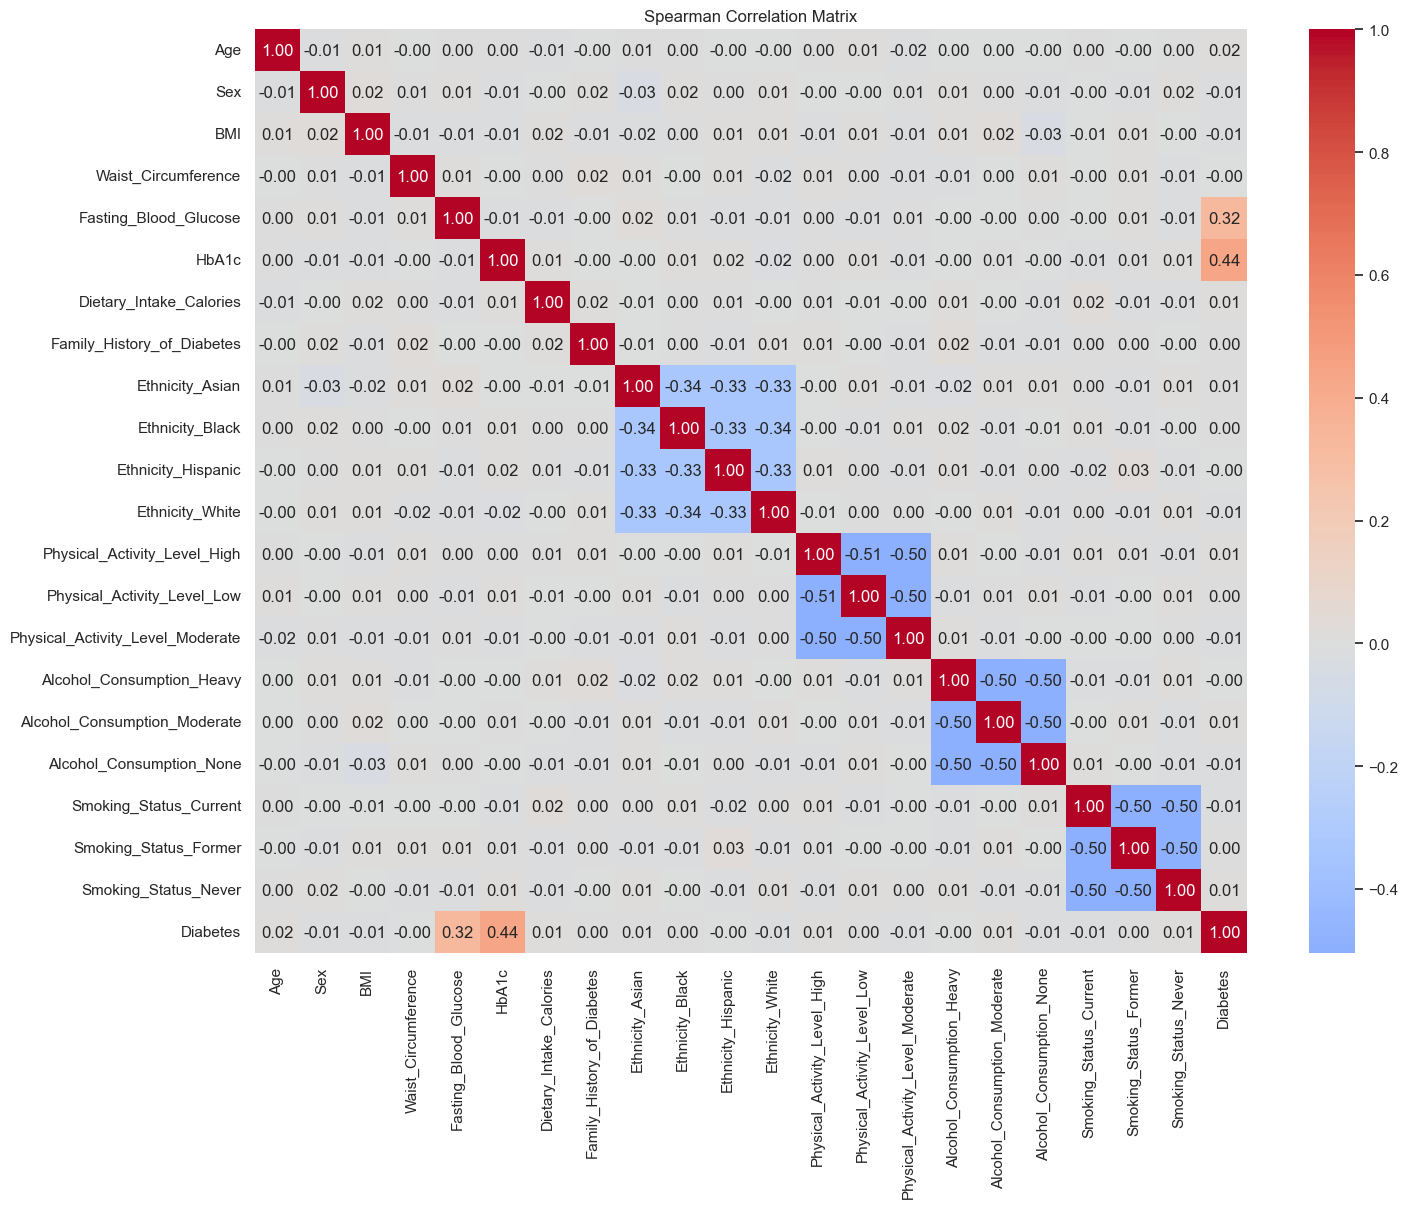

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spearman correlation
spearman_corr = df.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Spearman Correlation Matrix")
plt.show()


In [23]:
continuous_features = [
    "Age","sex", "BMI", "Waist_Circumference", "Fasting_Blood_Glucose", "HbA1c", "Dietary_Intake_Calories","Family_History_of_Diabetes"
]

# Keep only columns that exist (safety)
continuous_features = [c for c in continuous_features if c in df1.columns]
continuous_features


['Age',
 'BMI',
 'Waist_Circumference',
 'Fasting_Blood_Glucose',
 'HbA1c',
 'Dietary_Intake_Calories',
 'Family_History_of_Diabetes']

In [ ]:
ttest_results = []

group0 = df[df["Diabetes"] == 0]
group1 = df[df["Diabetes"] == 1]

for col in continuous_features:
    stat, p = ttest_ind(group0[col], group1[col], equal_var=False, nan_policy="omit")
    ttest_results.append({
        "Feature": col,
        "Test": "Welch t-test",
        "Statistic": stat,
        "p_value": p,
        "Mean_Diabetes0": group0[col].mean(),
        "Mean_Diabetes1": group1[col].mean()
    })

ttest_df = pd.DataFrame(ttest_results).sort_values("p_value")
ttest_df


,Feature,Test,Statistic,p_value,Mean_Diabetes0,Mean_Diabetes1
3,Fasting_Blood_Glucose,Welch t-test,-63.454029,0.000000,97.472928,138.705692
4,HbA1c,Welch t-test,-121.067169,0.000000,5.236831,9.957378
0,Age,Welch t-test,-1.656780,0.097831,43.905561,44.695700
1,BMI,Welch t-test,0.825791,0.409093,29.577650,29.401349
5,Dietary_Intake_Calories,Welch t-test,-0.711102,0.477163,2726.899265,2744.123356
2,Waist_Circumference,Welch t-test,0.269507,0.787587,94.916055,94.784536
6,Family_History_of_Diabetes,Welch t-test,-0.079728,0.936467,0.505771,0.507129


In [15]:
sig_ttest = ttest_df[ttest_df["p_value"] < 0.05]
print("✅ Significant continuous features (p < 0.05):", sig_ttest.shape[0])
sig_ttest


✅ Significant continuous features (p < 0.05): 2


,Feature,Test,Statistic,p_value,Mean_Diabetes0,Mean_Diabetes1
3,Fasting_Blood_Glucose,Welch t-test,-63.454029,0.0,97.472928,138.705692
4,HbA1c,Welch t-test,-121.067169,0.0,5.236831,9.957378


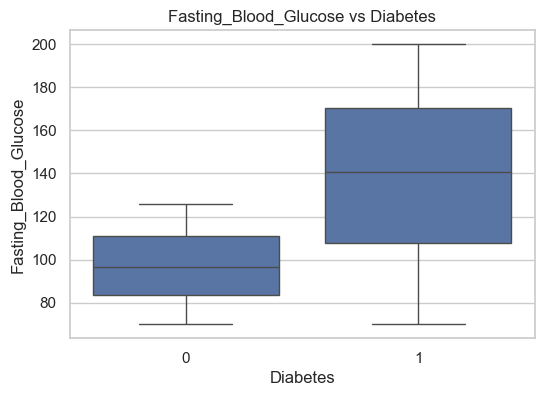

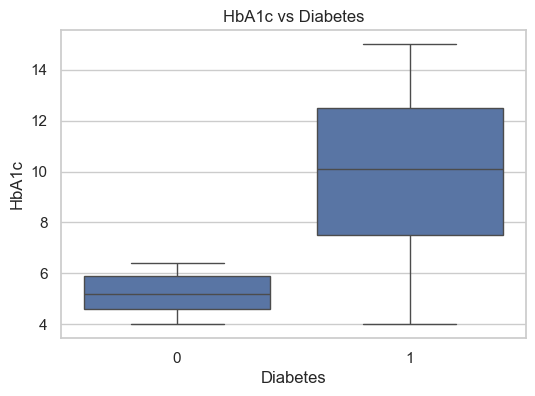

In [16]:
top = sig_ttest["Feature"].head(5).tolist()

for col in top:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Diabetes", y=col, data=df)
    plt.title(f"{col} vs Diabetes")
    plt.show()


In [17]:
# binary columns that look like one-hot (0/1), excluding target
binary_cols = [
    c for c in df.columns
    if c != "Diabetes"
    and df[c].nunique() == 2
    and set(df[c].dropna().unique()).issubset({0, 1})
]

print("✅ Number of binary/one-hot columns found:", len(binary_cols))
binary_cols[:20]


✅ Number of binary/one-hot columns found: 15


['Sex',
 'Family_History_of_Diabetes',
 'Ethnicity_Asian',
 'Ethnicity_Black',
 'Ethnicity_Hispanic',
 'Ethnicity_White',
 'Physical_Activity_Level_High',
 'Physical_Activity_Level_Low',
 'Physical_Activity_Level_Moderate',
 'Alcohol_Consumption_Heavy',
 'Alcohol_Consumption_Moderate',
 'Alcohol_Consumption_None',
 'Smoking_Status_Current',
 'Smoking_Status_Former',
 'Smoking_Status_Never']

In [18]:
chi_results = []

for col in binary_cols:
    table = pd.crosstab(df[col], df["Diabetes"])
    
    # Must be 2x2 to run chi-square properly
    if table.shape != (2, 2):
        continue
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    chi_results.append({
        "Feature": col,
        "Test": "Chi-square",
        "Chi2": chi2,
        "p_value": p
    })

chi_df = pd.DataFrame(chi_results).sort_values("p_value")
chi_df


,Feature,Test,Chi2,p_value
8,Physical_Activity_Level_Moderate,Chi-square,1.947592,0.162847
6,Physical_Activity_Level_High,Chi-square,1.488510,0.222448
10,Alcohol_Consumption_Moderate,Chi-square,1.159235,0.281624
12,Smoking_Status_Current,Chi-square,0.866057,0.352049
5,Ethnicity_White,Chi-square,0.747390,0.387304
0,Sex,Chi-square,0.722185,0.395428
14,Smoking_Status_Never,Chi-square,0.700591,0.402585
11,Alcohol_Consumption_None,Chi-square,0.533918,0.464964
2,Ethnicity_Asian,Chi-square,0.225184,0.635118
3,Ethnicity_Black,Chi-square,0.122156,0.726707


In [19]:
sig_chi = chi_df[chi_df["p_value"] < 0.05]
print("✅ Significant categorical/one-hot features (p < 0.05):", sig_chi.shape[0])
sig_chi.head(20)


✅ Significant categorical/one-hot features (p < 0.05): 0


,Feature,Test,Chi2,p_value


In [20]:
ttest_rank = ttest_df[["Feature", "Test", "p_value"]]
chi_rank = chi_df[["Feature", "Test", "p_value"]]

combined = pd.concat([ttest_rank, chi_rank], axis=0).sort_values("p_value")
combined["Significant(p<0.05)"] = combined["p_value"] < 0.05

combined.head(30)



,Feature,Test,p_value,Significant(p<0.05)
3,Fasting_Blood_Glucose,Welch t-test,0.000000,True
4,HbA1c,Welch t-test,0.000000,True
0,Age,Welch t-test,0.097831,False
8,Physical_Activity_Level_Moderate,Chi-square,0.162847,False
6,Physical_Activity_Level_High,Chi-square,0.222448,False
10,Alcohol_Consumption_Moderate,Chi-square,0.281624,False
12,Smoking_Status_Current,Chi-square,0.352049,False
5,Ethnicity_White,Chi-square,0.387304,False
0,Sex,Chi-square,0.395428,False
14,Smoking_Status_Never,Chi-square,0.402585,False


In [21]:
ttest_df.to_csv("../data/ttest_results.csv", index=False)
chi_df.to_csv("../data/chi_square_results.csv", index=False)
combined.to_csv("../data/statistical_test_results_combined.csv", index=False)

print("✅ Saved:")
print("- ../data/ttest_results.csv")
print("- ../data/chi_square_results.csv")
print("- ../data/statistical_test_results_combined.csv")


✅ Saved:
- ../data/ttest_results.csv
- ../data/chi_square_results.csv
- ../data/statistical_test_results_combined.csv
